<a href="https://colab.research.google.com/github/imets01/synthetic_network_data_gen/blob/anna/low_level_features/low_level_synthetic_data_PARSynthetizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install torch pandas numpy scikit-learn tqdm

In [2]:
!git clone https://github.com/imets01/synthetic_network_data_gen.git

Cloning into 'synthetic_network_data_gen'...
remote: Enumerating objects: 983, done.
remote: Counting objects: 100% (262/262), done.
remote: Compressing objects: 100% (190/190), done.
^C


In [3]:
%cd synthetic_network_data_gen
!git fetch
!git checkout anna

[Errno 2] No such file or directory: 'synthetic_network_data_gen'
/content
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [ ]:
high_level_csv = '/content/synthetic_network_data_gen/high_level_features/quiche/quiche_all_extracted_high_level_features.csv'
low_level_dir = '/content/synthetic_network_data_gen/low_level_features/quiche'

## Trying out PARSynthetizer from SDV

In [2]:
%pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.5/198.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.5/198.5 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.0 MB/s eta 0:00:00


In [3]:
from sdv.sequential import PARSynthesizer
from sdv.metadata import Metadata
import pandas as pd

In [4]:
data = pd.read_csv("https://raw.githubusercontent.com/imets01/synthetic_network_data_gen/refs/heads/anna/low_level_features/dataset/all_low_level_features_merged.csv")

In [5]:
metadata = Metadata.detect_from_dataframe(data)

In [6]:
def update_metadata(metadata, cols, correct_metadata, computer_representation = None):
  for i in range(len(cols)):
    metadata.update_column(
      column_name=cols[i],
      sdtype=correct_metadata,
    )
    if computer_representation is not None:
      metadata.update_column(
        column_name=cols[i],
        computer_representation=computer_representation,
      )
  return metadata

In [7]:
integer_cols = ['packet_length', 'count_initial', 'count_0rtt', 'count_handshake',
                'count_retry', 'count_vn', 'count_1rtt', 'count_ack', 'count_padding', 'count_connection_close',
                'count_path_challenge', 'count_path_response', 'count_new_connection_id',
                'count_retire_cid', 'count_crypto', 'count_handshake_done', 'count_ping', 'http3_stream_count',
                'http3_fin_count', 'stream_length', 'stream_type_count']
binary_cols = ['packet_direction', 'header_form']

In [8]:
metadata = update_metadata(metadata, binary_cols, 'boolean')
metadata = update_metadata(metadata, integer_cols, 'numerical', 'Int64')


In [9]:
metadata.set_sequence_key('capture_id')

In [10]:
metadata.set_sequence_index('frame_number')

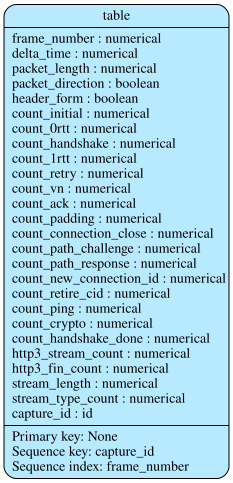

In [11]:
metadata.visualize()

In [12]:
data[binary_cols] = data[binary_cols].astype(bool)

In [13]:
import torch
torch.cuda.is_available()

True

In [13]:
value_counts = pd.DataFrame(data['capture_id'].value_counts())

Min length: count    1
dtype: int64
Mean length: count    21.928973
dtype: float64
Max length: count    32
dtype: int64


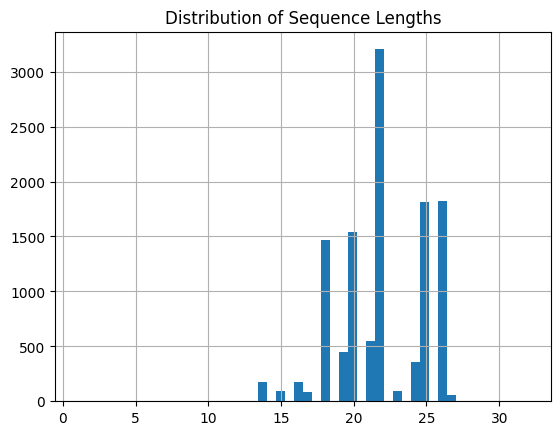

In [15]:


print("Min length:", value_counts.min())
print("Mean length:", value_counts.mean())
print("Max length:", value_counts.max())  # <--- If this is > 500, that's your problem.

# Visual check (optional)
import matplotlib.pyplot as plt
value_counts.hist(bins=50)
plt.title("Distribution of Sequence Lengths")
plt.show()

In [15]:
value_counts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11911 entries, 10055 to 11896
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   count   11911 non-null  int64
dtypes: int64(1)
memory usage: 186.1 KB


In [16]:
valid_ids = value_counts[value_counts['count']>5].index

In [17]:
clean_data = data[data['capture_id'].isin(valid_ids)]

In [18]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 261182 entries, 0 to 261195
Data columns (total 26 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   frame_number             261182 non-null  int64  
 1   delta_time               261182 non-null  float64
 2   packet_length            261182 non-null  int64  
 3   packet_direction         261182 non-null  bool   
 4   header_form              261182 non-null  bool   
 5   count_initial            261182 non-null  int64  
 6   count_0rtt               261182 non-null  int64  
 7   count_handshake          261182 non-null  int64  
 8   count_1rtt               261182 non-null  int64  
 9   count_retry              261182 non-null  int64  
 10  count_vn                 261182 non-null  int64  
 11  count_ack                261182 non-null  int64  
 12  count_padding            261182 non-null  int64  
 13  count_connection_close   261182 non-null  int64  
 14  count_pat

In [ ]:
from sdv.sequential import PARSynthesizer

synthesizer = PARSynthesizer(metadata, verbose=True, epochs=10, cuda=True)
synthesizer.fit(clean_data)

synthetic_data = synthesizer.sample(num_sequences=100)

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Loss (0.003):  10%|█         | 1/10 [06:12<55:49, 372.21s/it]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
synthetic_data

In [ ]:
output_path = '/content/drive/My Drive/MAP/my_final_dataframe.csv'

synthetic_data.to_csv(output_path, index=False)

print(f"✅ DataFrame successfully saved to: {output_path}")

In [ ]:
synthetic_data[synthetic_data['capture_id'] == 10283550]

,frame_number,delta_time,packet_length,packet_direction,header_form,count_initial,count_0rtt,count_handshake,count_1rtt,count_retry,count_vn,count_ack,count_padding,count_connection_close,count_path_challenge,count_path_response,count_new_connection_id,count_retire_cid,count_crypto,count_handshake_done,http3_stream_count,http3_fin_count,stream_length,stream_type_count,capture_id
81,1,0.000154,810,True,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,51,0,10283550
82,2,0.000183,75,False,True,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,10283550
83,3,-0.000010,1068,False,True,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10283550
84,4,-0.000010,517,True,False,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,3,0,10283550
85,5,0.001179,1049,True,False,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,5,0,10283550
86,6,0.000923,75,True,False,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10283550
87,7,-0.000010,198,True,False,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,2,0,10283550
88,8,-0.000010,75,True,False,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,4,1,10283550
89,9,-0.000010,300,False,False,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,25,1,10283550
90,10,0.000619,422,True,False,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,10283550


In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
pd.set_option('display.max_rows', None)

In [ ]:
display(synthetic_data)

,frame_number,delta_time,packet_length,packet_direction,header_form,count_initial,count_0rtt,count_handshake,count_1rtt,count_retry,count_vn,count_ack,count_padding,count_connection_close,count_path_challenge,count_path_response,count_new_connection_id,count_retire_cid,count_crypto,count_handshake_done,http3_stream_count,http3_fin_count,stream_length,stream_type_count,capture_id
0,1,0.000439,795,False,True,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,15,0,3159657
1,2,-0.000010,860,True,True,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,3159657
2,3,0.000566,119,True,False,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,3159657
3,4,0.001087,408,False,True,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,3159657
4,5,0.001295,75,True,False,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,6,0,3159657
5,6,0.001658,805,True,False,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,2,0,3159657
6,7,0.000883,857,True,False,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3159657
7,8,0.000386,333,True,False,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,3159657
8,9,0.001356,75,False,False,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,3159657
9,10,0.000714,806,True,False,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,4,1,3159657
